# EDA

data source:

 `data/document_metrics.csv`



In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

metrics_path = Path("data/document_metrics.csv")
metrics = pd.read_csv(metrics_path, encoding="utf-8-sig")

In [16]:
metrics

,ticker,source_file,total_word_count,ai_candidate_passage_count,ai_candidate_word_count,ai_candidate_word_share,ai_mention_count,ai_mentions_per_1000_words
0,MSFT,MSFT_10K_2026-07-29.txt,47809,101,12357,0.258466,175,3.660399
1,WMT,WMT_10K_2026-03-13.txt,53778,19,3842,0.071442,25,0.464874
2,JPM,JPM_10K_2026-02-13.txt,177035,20,1090,0.006157,30,0.169458


In [17]:
metrics.dtypes.to_frame(name="dtype")

,dtype
ticker,str
source_file,str
total_word_count,int64
ai_candidate_passage_count,int64
ai_candidate_word_count,int64
ai_candidate_word_share,float64
ai_mention_count,int64
ai_mentions_per_1000_words,float64


In [18]:
CONFIG = {
    "company_col": "ticker",
    "top_n": None,                 # None = all companies; or 10, 20, etc.
    "sort_by": "ai_mentions_per_1000_words",
    "ascending": False,
    "figsize": (9, 5),
    "save_figures": False,
    "output_dir": "figures",
}

df = metrics.copy()

numeric_cols = [
    "total_word_count",
    "ai_candidate_passage_count",
    "ai_candidate_word_count",
    "ai_candidate_word_share",
    "ai_mention_count",
    "ai_mentions_per_1000_words",
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df = df.sort_values(
    CONFIG["sort_by"],
    ascending=CONFIG["ascending"]
)

if CONFIG["top_n"] is not None:
    df = df.head(CONFIG["top_n"])

df = df.reset_index(drop=True)

print(f"Number of companies: {len(df)}")
display(df)

Number of companies: 3


,ticker,source_file,total_word_count,ai_candidate_passage_count,ai_candidate_word_count,ai_candidate_word_share,ai_mention_count,ai_mentions_per_1000_words
0,MSFT,MSFT_10K_2026-07-29.txt,47809,101,12357,0.258466,175,3.660399
1,WMT,WMT_10K_2026-03-13.txt,53778,19,3842,0.071442,25,0.464874
2,JPM,JPM_10K_2026-02-13.txt,177035,20,1090,0.006157,30,0.169458


In [19]:
summary = df[numeric_cols].describe().T

summary = summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(summary.round(4))

,count,mean,std,min,25%,50%,75%,max
total_word_count,3.0,92874.0000,72946.6427,47809.0000,50793.5000,53778.0000,115406.5000,177035.0000
ai_candidate_passage_count,3.0,46.6667,47.0567,19.0000,19.5000,20.0000,60.5000,101.0000
ai_candidate_word_count,3.0,5763.0000,5874.0108,1090.0000,2466.0000,3842.0000,8099.5000,12357.0000
ai_candidate_word_share,3.0,0.1120,0.1310,0.0062,0.0388,0.0714,0.1650,0.2585
ai_mention_count,3.0,76.6667,85.1959,25.0000,27.5000,30.0000,102.5000,175.0000
ai_mentions_per_1000_words,3.0,1.4316,1.9359,0.1695,0.3172,0.4649,2.0626,3.6604


In [20]:
comparison = df[
    [
        CONFIG["company_col"],
        "total_word_count",
        "ai_candidate_passage_count",
        "ai_mention_count",
        "ai_mentions_per_1000_words",
        "ai_candidate_word_share",
    ]
].copy()

comparison["ai_candidate_word_share"] *= 100

comparison = comparison.rename(columns={
    "total_word_count": "Document Words",
    "ai_candidate_passage_count": "Candidate Passages",
    "ai_mention_count": "AI Mentions",
    "ai_mentions_per_1000_words": "Mentions per 1K Words",
    "ai_candidate_word_share": "Candidate Word Share (%)",
})

display(comparison.round(2))

,ticker,Document Words,Candidate Passages,AI Mentions,Mentions per 1K Words,Candidate Word Share (%)
0,MSFT,47809,101,175,3.66,25.85
1,WMT,53778,19,25,0.46,7.14
2,JPM,177035,20,30,0.17,0.62


In [21]:
def plot_bar(data, column, title=None, xlabel=None,
             multiplier=1, decimals=2):

    plot_df = data.sort_values(column, ascending=True)

    fig, ax = plt.subplots(figsize=CONFIG["figsize"])

    values = plot_df[column] * multiplier

    bars = ax.barh(
        plot_df[CONFIG["company_col"]].astype(str),
        values
    )

    ax.set_title(title or column)
    ax.set_xlabel(xlabel or column)
    ax.set_ylabel("")

    ax.bar_label(
        bars,
        fmt=f"%.{decimals}f",
        padding=4
    )

    ax.set_xlim(0, max(values.max(), 0) * 1.2 if len(values) else 1)

    plt.tight_layout()

    if CONFIG["save_figures"]:
        output_dir = Path(CONFIG["output_dir"])
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            output_dir / f"{column}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

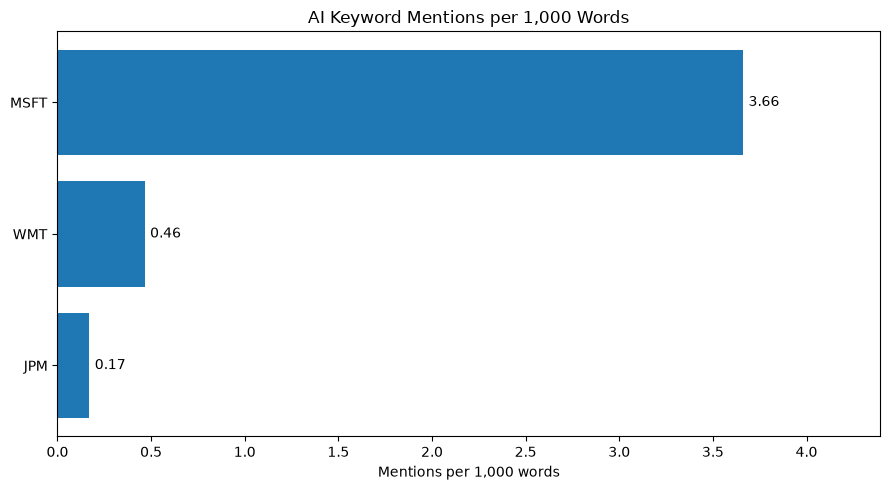

In [22]:
plot_bar(
    df,
    column="ai_mentions_per_1000_words",
    title="AI Keyword Mentions per 1,000 Words",
    xlabel="Mentions per 1,000 words"
)

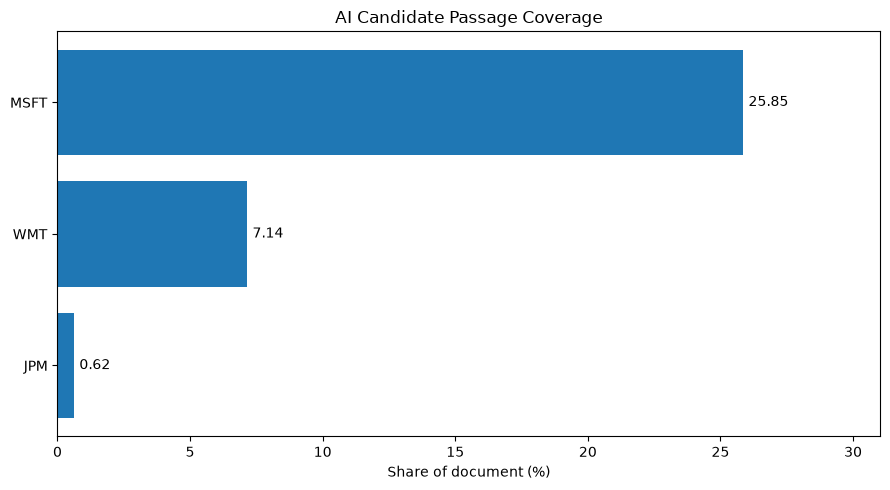

In [23]:
plot_bar(
    df,
    column="ai_candidate_word_share",
    title="AI Candidate Passage Coverage",
    xlabel="Share of document (%)",
    multiplier=100
)

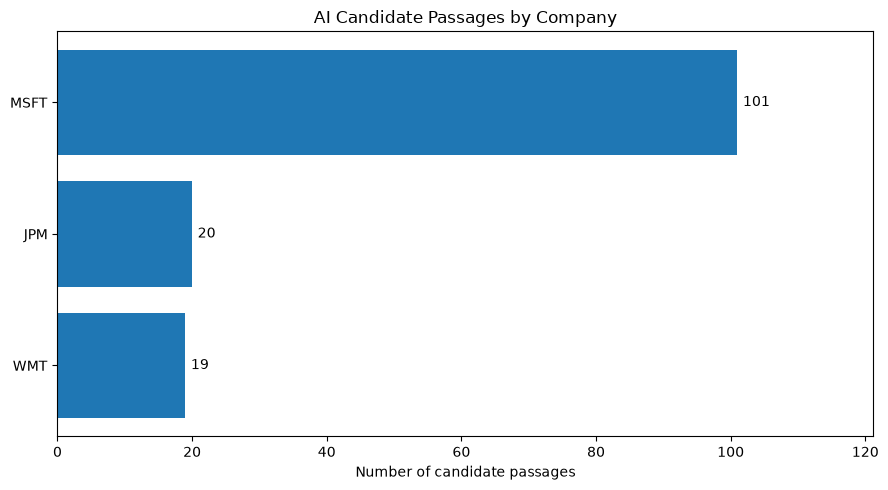

In [24]:
plot_bar(
    df,
    column="ai_candidate_passage_count",
    title="AI Candidate Passages by Company",
    xlabel="Number of candidate passages",
    decimals=0
)

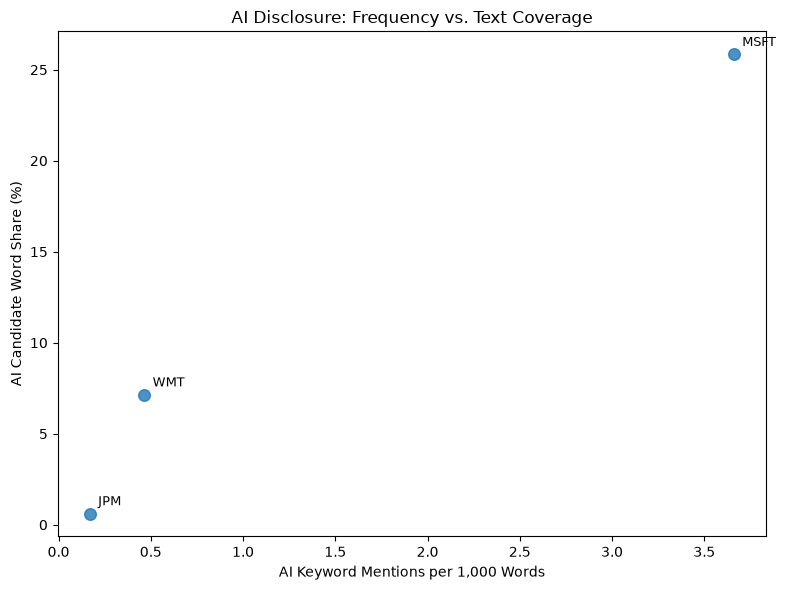

In [25]:
x_col = "ai_mentions_per_1000_words"
y_col = "ai_candidate_word_share"

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df[x_col],
    df[y_col] * 100,
    s=70,
    alpha=0.8
)

for _, row in df.iterrows():
    ax.annotate(
        str(row[CONFIG["company_col"]]),
        (row[x_col], row[y_col] * 100),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel("AI Keyword Mentions per 1,000 Words")
ax.set_ylabel("AI Candidate Word Share (%)")
ax.set_title("AI Disclosure: Frequency vs. Text Coverage")

plt.tight_layout()
plt.show()

In [26]:
ANNOTATION_CONFIG = {
    "path": Path("data/ai_annotations.csv"),
    "company_col": "ticker",
    "period_col": "report_period",
    "stage_col": "adoption_stage",
    "figsize": (10, 5),
    "top_n": None,
    "min_confidence": None,   # None, "medium", or "high"
    "substantive_only": True,
}

annotation_path = ANNOTATION_CONFIG["path"]

if annotation_path.exists():
    annotations = pd.read_csv(
        annotation_path,
        dtype="string",
        keep_default_na=False
    )

    print(f"Loaded {len(annotations)} annotation rows")
    display(annotations.head())

else:
    annotations = pd.DataFrame()
    print("Annotation dataset not available yet.")


Annotation dataset not available yet.


In [27]:
EXPECTED_COLUMNS = {
    "ticker",
    "passage_id",
    "claim_id",
    "ai_relevance",
    "adoption_stage",
    "strategy_specificity",
    "application_scope",
    "strategic_orientation",
    "reported_deployment",
    "quantified_outcome",
    "coding_confidence",
    "needs_human_review",
}

if not annotations.empty:

    missing_cols = EXPECTED_COLUMNS - set(annotations.columns)

    if missing_cols:
        print("Missing expected columns:", sorted(missing_cols))

    # Work on a copy
    ann = annotations.copy()

    # Normalize common missing values
    ann = ann.replace(
        ["", "NA", "N/A", "null", "None"],
        pd.NA
    )

    # Convert numerical metrics
    for col in ["adoption_stage", "strategy_specificity"]:
        if col in ann.columns:
            ann[col] = pd.to_numeric(
                ann[col],
                errors="coerce"
            )

    # Consistent text labels
    for col in [
        "ai_relevance",
        "coding_confidence",
        "reported_deployment",
        "quantified_outcome",
    ]:
        if col in ann.columns:
            ann[col] = ann[col].str.lower().str.strip()

    display(
        ann.dtypes.to_frame("dtype")
    )

In [ ]:
if not ann.empty:

    company_col = ANNOTATION_CONFIG["company_col"]

    companies = sorted(ann[company_col].dropna().unique())

    # Change this to any company in the dataset
    SELECTED_COMPANY = companies[0]

    company_data = ann[
        ann[company_col] == SELECTED_COMPANY
    ].copy()

    # Count unique passages, not split claims.
    relevance_order = [
        "substantive",
        "context_only",
        "irrelevant",
        "uncertain"
    ]

    passage_relevance = (
        company_data
        .groupby("passage_id")["ai_relevance"]
        .agg(
            lambda s: (
                "substantive" if "substantive" in s.values
                else "uncertain" if "uncertain" in s.values
                else "context_only" if "context_only" in s.values
                else "irrelevant"
            )
        )
    )

    relevance_counts = (
        passage_relevance
        .value_counts()
        .reindex(relevance_order, fill_value=0)
    )

    relevance_counts = relevance_counts[
        relevance_counts > 0
    ]

    if relevance_counts.empty:
        print("No relevance data available.")
    else:
        fig, ax = plt.subplots(figsize=(7, 6))

        wedges, _, autotexts = ax.pie(
            relevance_counts,
            autopct=lambda p: f"{p:.1f}%" if p >= 4 else "",
            startangle=90,
            pctdistance=0.82,
            wedgeprops={"width": 0.4}
        )

        ax.text(
            0, 0,
            f"{len(passage_relevance)}\nPassages",
            ha="center",
            va="center",
            fontsize=13
        )

        ax.legend(
            wedges,
            relevance_counts.index,
            title="AI Relevance",
            loc="center left",
            bbox_to_anchor=(1, 0.5)
        )

        ax.set_title(
            f"AI Relevance Distribution — {SELECTED_COMPANY}"
        )

        plt.tight_layout()
        plt.show()

    display(relevance_counts)

In [ ]:
if not annotations.empty:

    stage_pct = (
        stage_table.div(
            stage_table.sum(axis=1).replace(0, np.nan),
            axis=0
        ) * 100
    )

    display(stage_pct.round(2))

    stage_pct.plot(
        kind="bar",
        stacked=True,
        figsize=ANNOTATION_CONFIG["figsize"]
    )

    plt.title("AI Adoption Evidence Distribution (%)")
    plt.xlabel("Company")
    plt.ylabel("Share of Classified Claims (%)")
    plt.legend(
        title="Adoption Stage",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
if not annotations.empty:

    specificity_data = ann.dropna(
        subset=["adoption_stage", "strategy_specificity"]
    ).copy()

    specificity_summary = (
        specificity_data
        .groupby("adoption_stage")["strategy_specificity"]
        .agg(["count", "mean", "median"])
        .reset_index()
        .sort_values("adoption_stage")
    )

    display(specificity_summary.round(2))

    fig, ax = plt.subplots(
        figsize=ANNOTATION_CONFIG["figsize"]
    )

    ax.scatter(
        specificity_data["adoption_stage"],
        specificity_data["strategy_specificity"],
        alpha=0.4
    )

    ax.set_xlabel("Reported Adoption Stage")
    ax.set_ylabel("Strategy Specificity")
    ax.set_title("Strategy Specificity vs. Adoption Evidence")

    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_yticks([1, 2, 3, 4, 5])

    plt.tight_layout()
    plt.show()